In [17]:
import pandas as pd
import yaml

import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
from typing import Tuple

from pandas import DataFrame

def read_peptides_data() -> Tuple[pd.DataFrame, pd.DataFrame]:
    df, df2 = pd.DataFrame(), pd.DataFrame()
    for i in range(1, 27):
        metadata = yaml.safe_load(
            open(f'../results/peptides-{i}.yml')
        )
        results = pd.read_csv(f'../results/results-peptides-predictor-{i}.csv')
        test_results = results[~results['mcc'].isna()].reset_index(drop=True)
        valid_results = results[results['mcc'].isna()].reset_index(drop=True)
        valid_results = valid_results.iloc[valid_results['epoch'].idxmax()]

        test_results['alpha'] = metadata['alpha'][0]
        test_results['gamma'] = metadata['gamma']
        test_results['hidden_state'] = metadata['hidden_state']
        test_results['layers'] = metadata['layers']
        test_results['exp-number'] = i

        valid_results['alpha'] = metadata['alpha'][0]
        valid_results['gamma'] = metadata['gamma']
        valid_results['hidden_state'] = metadata['hidden_state']
        valid_results['layers'] = metadata['layers']
        valid_results['exp-number'] = i

        df = pd.concat([df, test_results])
        df2 = pd.concat([df2, valid_results], axis=1)

    return df, df2.T


def read_sites_data() -> Tuple[pd.DataFrame, pd.DataFrame]:
    df, df2 = pd.DataFrame(), pd.DataFrame()
    for i in range(1, 45):
        metadata = yaml.safe_load(
            open(f'../results/sites-{i}.yml')
        )
        results = pd.read_csv(f'../results/results-sites-predictor-{i}.csv')
        test_results = results[~results['mcc'].isna()].reset_index(drop=True)
        valid_results = results[results['mcc'].isna()].reset_index(drop=True)
        valid_results = valid_results.iloc[valid_results['epoch'].idxmax()]

        test_results['alpha'] = metadata['alpha'][0]
        test_results['gamma'] = metadata['gamma']
        test_results['hidden_state'] = metadata['hidden_state']
        test_results['layers'] = metadata['layers']
        test_results['exp-number'] = i

        valid_results['alpha'] = metadata['alpha'][0]
        valid_results['gamma'] = metadata['gamma']
        valid_results['hidden_state'] = metadata['hidden_state']
        valid_results['layers'] = metadata['layers']
        valid_results['exp-number'] = i

        df = pd.concat([df, test_results])
        df2 = pd.concat([df2, valid_results], axis=1)

    return df, df2.T

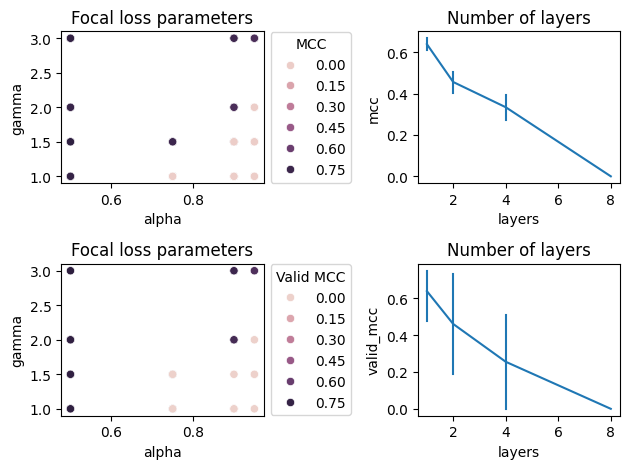

In [19]:
df, df2 = read_peptides_data()
plt.subplot(2, 2, 1)
ax1 = sns.scatterplot(data=df, x='alpha', y='gamma', hue='mcc')
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='MCC')
ax1.set_title("Focal loss parameters")

plt.subplot(2, 2, 2)
ax2 = sns.lineplot(data=df, x='layers', y='mcc', err_style='bars')
ax2.set_title("Number of layers")

plt.subplot(2, 2, 3)
ax3 = sns.scatterplot(data=df2, x='alpha', y='gamma', hue='valid_mcc')
ax3.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='Valid MCC')
ax3.set_title("Focal loss parameters")

plt.subplot(2, 2, 4)
ax4 = sns.lineplot(data=df2, x='layers', y='valid_mcc', err_style='bars')
ax4.set_title("Number of layers")

plt.tight_layout()

In [20]:
avg_mcc = df.groupby('exp-number')['mcc'].mean()

best_exp = avg_mcc.idxmax()
best_value = avg_mcc.max()

print("Best MCC is: ", f'{best_value:.3f}')
print("Best recall is: ", f'{df.loc[df['exp-number'] == best_exp, 'recall_weighted'].mean():.3f}')
print("Best precision is: ", f'{df.loc[df['exp-number'] == best_exp, 'precision_weighted'].mean():.3f}')
print(df.loc[df['exp-number'] == best_exp].iloc[0, -5:])

Best MCC is:  0.775
Best recall is:  0.910
Best precision is:  0.910
alpha           0.5
gamma           3.0
hidden_state    320
layers            1
exp-number        9
Name: 0, dtype: object


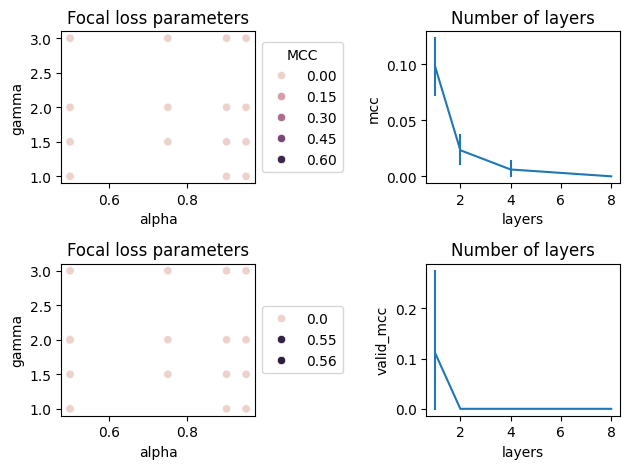

In [21]:
df, df2 = read_sites_data()
plt.subplot(2, 2, 1)
ax1 = sns.scatterplot(data=df, x='alpha', y='gamma', hue='mcc')
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='MCC')
ax1.set_title("Focal loss parameters")

plt.subplot(2, 2, 2)
ax2 = sns.lineplot(data=df, x='layers', y='mcc', err_style='bars')
ax2.set_title("Number of layers")

plt.subplot(2, 2, 3)
ax3 = sns.scatterplot(data=df2, x='alpha', y='gamma', hue='valid_mcc')
ax3.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='Valid MCC')
ax3.set_title("Focal loss parameters")
handles, labels = ax3.get_legend_handles_labels()
new_labels = [labels[0]] + [f"{float(l):.2f}" for l in labels[1:]]
ax3.legend(handles, new_labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.subplot(2, 2, 4)
ax4 = sns.lineplot(data=df2, x='layers', y='valid_mcc', err_style='bars')
ax4.set_title("Number of layers")

plt.tight_layout()

In [22]:
avg_mcc = df.groupby('exp-number')['mcc'].mean()

best_exp = avg_mcc.idxmax()
best_value = avg_mcc.max()

print("Best MCC is: ", f'{best_value:.3f}')
print("Best recall is: ", f'{df.loc[df['exp-number'] == best_exp, 'recall_weighted'].mean():.3f}')
print("Best precision is: ", f'{df.loc[df['exp-number'] == best_exp, 'precision_weighted'].mean():.3f}')
print(df.loc[df['exp-number'] == best_exp].iloc[0, -5:])

Best MCC is:  0.516
Best recall is:  0.984
Best precision is:  0.981
alpha           0.5
gamma           2.0
hidden_state    320
layers            1
exp-number        8
Name: 0, dtype: object
